### Data Preparation ###

In [1]:
# Imports
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
import numpy as np

In [2]:
data_sensors = pd.read_csv("Indoor_Plant_Health_and_Growth_Factors.csv")
data_optimal = pd.read_csv("optimal_plant_conditions.csv")

data = pd.merge(
    data_sensors,
    data_optimal,
    left_on='Plant_ID',
    right_on='Plant_ID',
    how='left'
)

In [3]:
# Drop irrelevant columns
data = data.drop(columns=["Fertilizer_Type", "Fertilizer_Amount_ml", "Pest_Presence", "Pest_Severity", "Soil_Type","Health_Score", "Height_cm", "Leaf_Count", "New_Growth_Count", "Health_Notes",  "Sunlight_Exposure"])
data

,Plant_ID,Watering_Amount_ml,Watering_Frequency_days,Room_Temperature_C,Humidity_%,Soil_Moisture_%,Optimal_Room_Temperature_C,Optimal_Humidity_%,Optimal_Soil_Moisture_%
0,Sansevieria cylindrica,205,3,21.7,77.5,51.9,24,35,25
1,Aloe vera,191,1,22.6,68.9,28.2,24,35,25
2,Ficus lyrata,477,5,17.2,44.3,13.6,24,50,45
3,Monstera deliciosa,207,1,25.0,72.2,38.4,25,70,65
4,Ficus lyrata,465,2,23.2,51.6,37.9,24,50,45
...,...,...,...,...,...,...,...,...,...
995,Sansevieria cylindrica,370,4,32.4,58.0,31.7,24,35,25
996,Schefflera arboricola,91,3,24.3,39.4,32.9,23,50,45
997,Monstera deliciosa,134,4,26.4,52.4,58.5,25,70,65
998,Epipremnum aureum,442,3,18.7,60.1,24.8,24,60,55


In [4]:
# Convert from milliliters to seconds for watering with the flow rate of 10ml/sec
data["Pump_time"] = data["Watering_Amount_ml"] / 10
data = data.drop(columns=["Watering_Amount_ml"])
data

,Plant_ID,Watering_Frequency_days,Room_Temperature_C,Humidity_%,Soil_Moisture_%,Optimal_Room_Temperature_C,Optimal_Humidity_%,Optimal_Soil_Moisture_%,Pump_time
0,Sansevieria cylindrica,3,21.7,77.5,51.9,24,35,25,20.5
1,Aloe vera,1,22.6,68.9,28.2,24,35,25,19.1
2,Ficus lyrata,5,17.2,44.3,13.6,24,50,45,47.7
3,Monstera deliciosa,1,25.0,72.2,38.4,25,70,65,20.7
4,Ficus lyrata,2,23.2,51.6,37.9,24,50,45,46.5
...,...,...,...,...,...,...,...,...,...
995,Sansevieria cylindrica,4,32.4,58.0,31.7,24,35,25,37.0
996,Schefflera arboricola,3,24.3,39.4,32.9,23,50,45,9.1
997,Monstera deliciosa,4,26.4,52.4,58.5,25,70,65,13.4
998,Epipremnum aureum,3,18.7,60.1,24.8,24,60,55,44.2


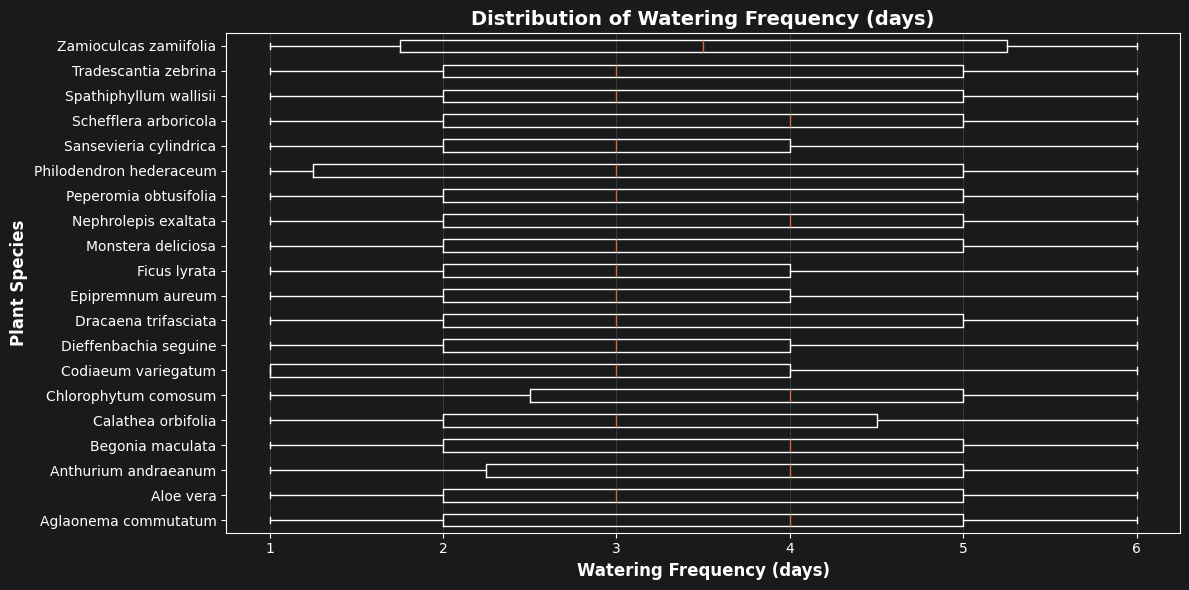

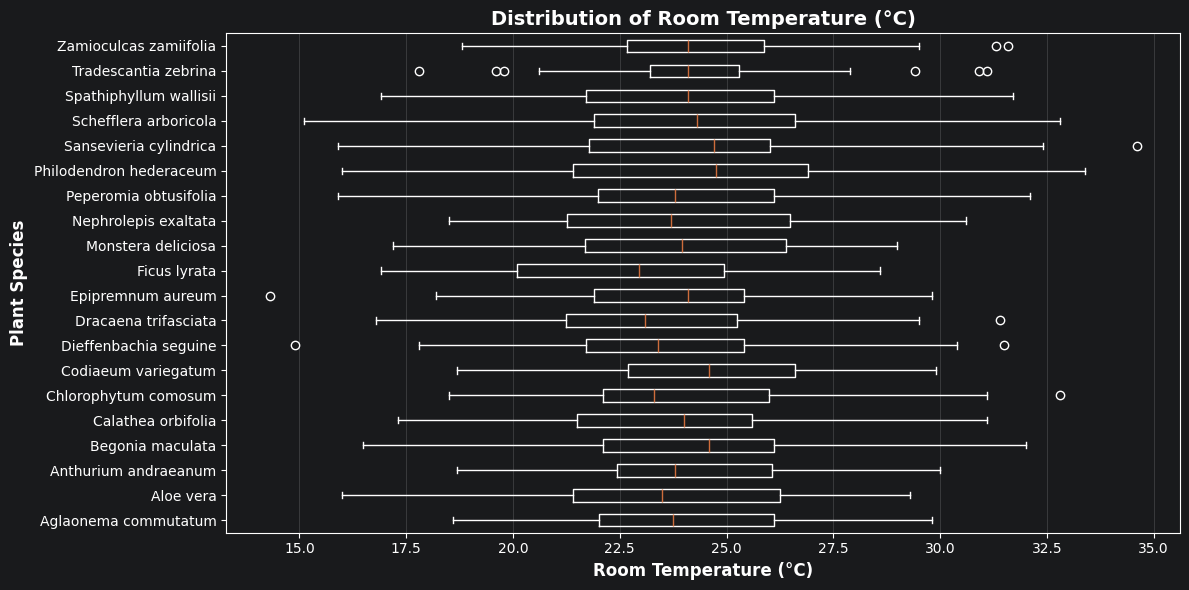

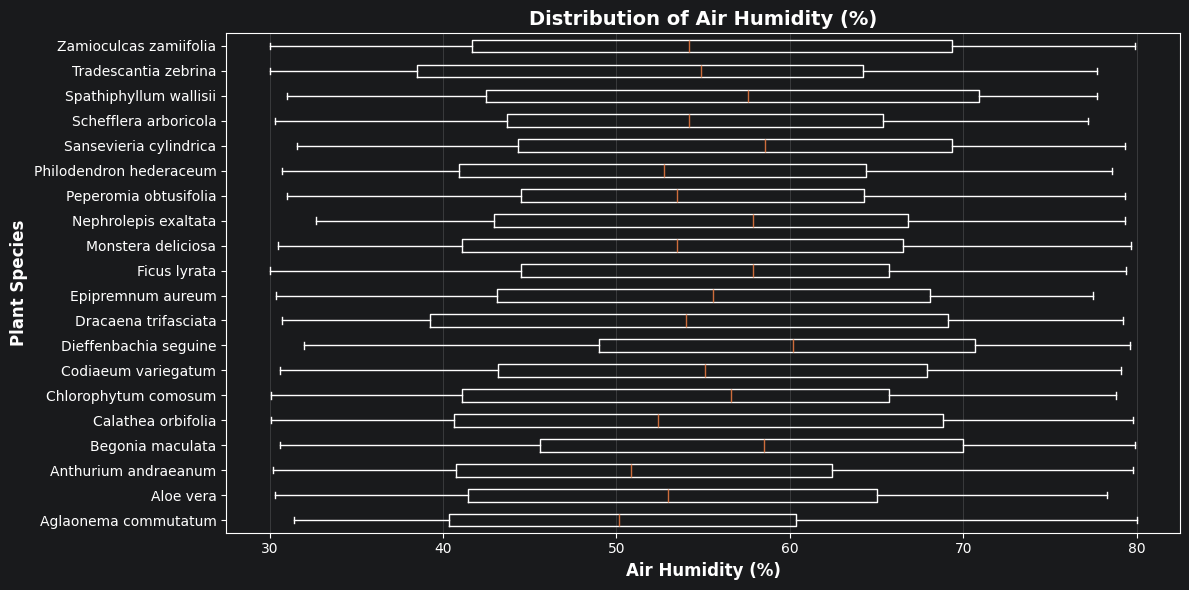

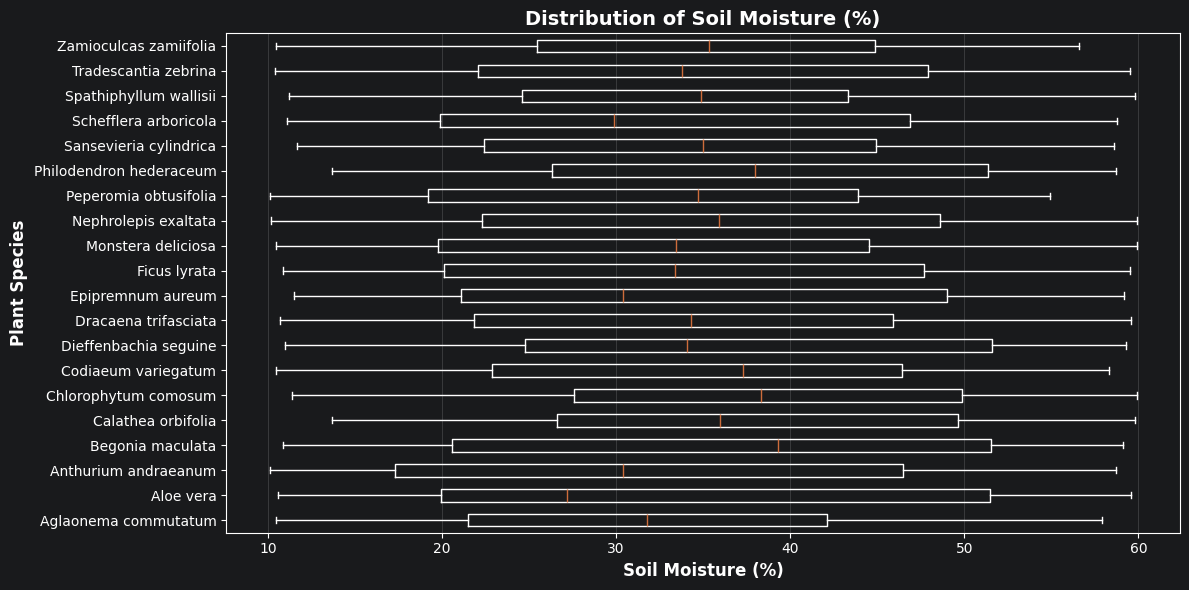

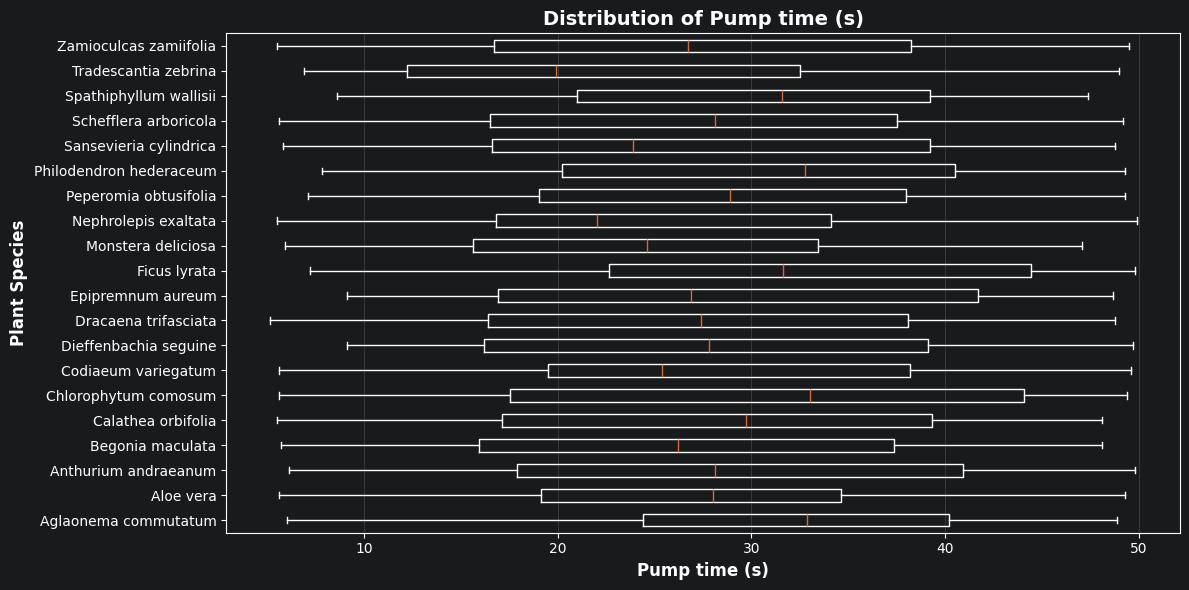

In [5]:
# Outliers
# Get unique plants
plants = sorted(data['Plant_ID'].unique())

# Define metrics
metrics = ['Watering_Frequency_days', 'Room_Temperature_C', 'Humidity_%', 'Soil_Moisture_%', 'Pump_time']
metric_labels = ['Watering Frequency (days)', 'Room Temperature (°C)', 'Air Humidity (%)', 'Soil Moisture (%)', 'Pump time (s)']

# Create boxplots for each metric
for idx, (metric, label) in enumerate(zip(metrics, metric_labels)):

    fig, ax = plt.subplots(figsize=(12, 6))

    # Prepare data for each plant
    data_list = [data[data['Plant_ID'] == plant][metric].dropna().values for plant in plants]

    # Create horizontal boxplot
    ax.boxplot(data_list, tick_labels=plants, vert=False)
    ax.set_xlabel(label, fontsize=12, fontweight='bold')
    ax.set_ylabel('Plant Species', fontsize=12, fontweight='bold')
    ax.set_title(f'Distribution of {label}', fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='x')

    plt.tight_layout()
    plt.show()

In [6]:
# Feature Engineering

# Soil humidity deficit (optimal - current -> to get a positive value when it needs water)
data['soil_deficit'] = (data['Optimal_Soil_Moisture_%'] - data['Soil_Moisture_%'])

# Temperature deviation (current - optimal -> get a postive value when it's hotter than ideal)
data['temp_deviation'] = (data['Room_Temperature_C'] - data['Optimal_Room_Temperature_C'])

# Air humidity deficit (optimal - current -> positive means the air is too dry)
data['air_hum_deficit'] = (data['Optimal_Humidity_%'] - data['Humidity_%'])

data = data.drop(columns=["Optimal_Humidity_%", "Optimal_Room_Temperature_C", "Optimal_Soil_Moisture_%"])

data

,Plant_ID,Watering_Frequency_days,Room_Temperature_C,Humidity_%,Soil_Moisture_%,Pump_time,soil_deficit,temp_deviation,air_hum_deficit
0,Sansevieria cylindrica,3,21.7,77.5,51.9,20.5,-26.9,-2.3,-42.5
1,Aloe vera,1,22.6,68.9,28.2,19.1,-3.2,-1.4,-33.9
2,Ficus lyrata,5,17.2,44.3,13.6,47.7,31.4,-6.8,5.7
3,Monstera deliciosa,1,25.0,72.2,38.4,20.7,26.6,0.0,-2.2
4,Ficus lyrata,2,23.2,51.6,37.9,46.5,7.1,-0.8,-1.6
...,...,...,...,...,...,...,...,...,...
995,Sansevieria cylindrica,4,32.4,58.0,31.7,37.0,-6.7,8.4,-23.0
996,Schefflera arboricola,3,24.3,39.4,32.9,9.1,12.1,1.3,10.6
997,Monstera deliciosa,4,26.4,52.4,58.5,13.4,6.5,1.4,17.6
998,Epipremnum aureum,3,18.7,60.1,24.8,44.2,30.2,-5.3,-0.1


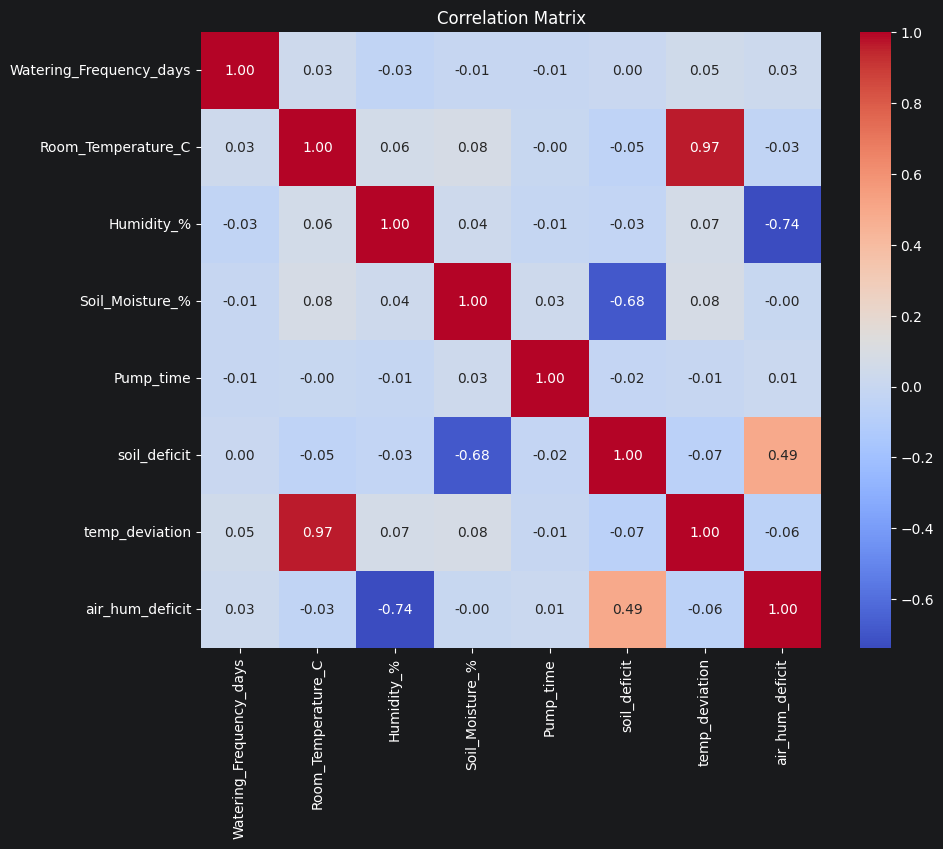

In [7]:
# Correlation matrix
numeric_data = data.select_dtypes(include=['float64', 'int64'])
correlation_matrix = numeric_data.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

### Train-Test Slip ###

In [8]:
# Data preparation
X = data.drop(columns=["Plant_ID"])
y = data["Plant_ID"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [9]:
rf = RandomForestClassifier(n_estimators=200, random_state=42)

rf.fit(X_train, y_train)

predictions = rf.predict(X_test)

accuracy = accuracy_score(y_test, predictions)

print(accuracy)

0.285


In [10]:
# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Tuning hyperparameter
neighbors_range = range(3, 20)
distance_metrics = ['euclidean', 'manhattan', 'minkowski']

# Variables to store the best parameters and highest accuracy
best_accuracy = 0
best_params = {'n_neighbors': None, 'metric': None}

# Nested loop to iterate over the hyperparameters
for n_neighbors in neighbors_range:
    for metric in distance_metrics:
        # Initialize the KNN model with current hyperparameters
        knn = KNeighborsClassifier(n_neighbors=n_neighbors, metric=metric)

        # Train the model
        knn.fit(X_train, y_train)

        # Make predictions on the test set
        predictions = knn.predict(X_test)

        # Calculate the accuracy
        accuracy = accuracy_score(y_test, predictions)

        # Update the best parameters if current accuracy is higher
        if accuracy > best_accuracy:
            best_accuracy = accuracy
            best_params['n_neighbors'] = n_neighbors
            best_params['metric'] = metric

# Print the best set of parameters and the highest accuracy achieved
print(f"Best parameters: Number of Neighbors - {best_params['n_neighbors']}, Distance Metric - {best_params['metric']}")
print(f"Highest Accuracy: {best_accuracy*100:.2f}%")

Best parameters: Number of Neighbors - 6, Distance Metric - manhattan
Highest Accuracy: 21.00%


In [11]:
# train a random forest classifier
n_features = X_train.shape[1]

rf_clf = RandomForestClassifier(n_estimators=100, max_depth=4, random_state=42, max_features=int(np.sqrt(n_features)))
rf_clf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",4
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",2
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_true,

In [12]:
# evaluate the random forest on the train set
train_accuracy_rf = rf_clf.score(X_train, y_train)
print(f"Train set accuracy of random forest: {train_accuracy_rf:.2f}")
# evaluate the random forest on the test set
accuracy_rf = rf_clf.score(X_test, y_test)
print(f"Test set accuracy of random forest: {accuracy_rf:.2f}")

Train set accuracy of random forest: 0.49
Test set accuracy of random forest: 0.14


In [13]:
# feature importance from the random forest
feature_importances = rf_clf.feature_importances_
feature_importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": feature_importances
}).sort_values(by="Importance", ascending=False)
print(feature_importance_df)



                   Feature  Importance
5             soil_deficit    0.287220
7          air_hum_deficit    0.240243
6           temp_deviation    0.103378
2               Humidity_%    0.102546
3          Soil_Moisture_%    0.098345
1       Room_Temperature_C    0.076549
4                Pump_time    0.061670
0  Watering_Frequency_days    0.030049


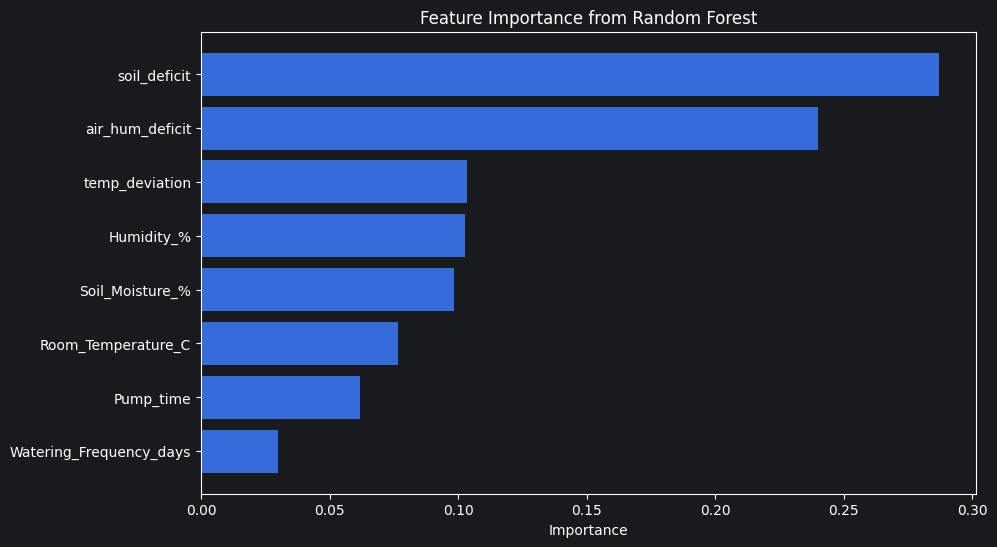

In [14]:
# visualize feature importance
plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df["Feature"], feature_importance_df["Importance"])
plt.xlabel("Importance")
plt.title("Feature Importance from Random Forest")
plt.gca().invert_yaxis()
plt.show()